# **`Inatel - C24 (Inteligência Artificial) - 2026/1`**

# <font color='green'>**Atividade 06: Classificação**</font>

## <font color='#2D9CDB'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte o material disponibilizado pelo Prof. Felipe Figueiredo para revisar os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**A ATIVIDADE DEVERÁ SER REALIZADA COM O [MONITOR](mailto:matheus.botelho@ges.inatel.br) EM UM DOS SEGUINTES HORÁRIOS:**</font>

| Monitor                       | Dia           | Hora                               | Local           |
|-------------------------------|---------------|------------------------------------|---------------- |
| Matheus Botelho Sampaio Netto | Terça-feira   | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Quinta-feira  | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>10:00</font> | Teams (ao vivo) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>13:30</font> | Teams (ao vivo) |

- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='#2D9CDB'>azul</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação.</font>
  - Exemplo: `!pip install nome_da_biblioteca`
- <font color='red'>**Renomeie os termos `LL` para `sua_turma_de_laboratorio` e `MMMM` para `seu_numero_de_matricula` no nome do arquivo.**</font>
  - Exemplo: `C24_2026_1_L1_Atividade_06_1234.ipynb`)
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

# <font color='green'><u><b>Preparação</b></u></font>

In [1]:
!pip install numpy pandas matplotlib seaborn scikit-learn ucimlrepo

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# <font color='green'><u><b>Parte 1 - Classificação Binária</b></u></font>

### <font color='#2D9CDB'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='#2D9CDB'>Iranian Churn Dataset (2020). UCI Machine Learning Repository.</font>
  - #### <font color='#2D9CDB'>https://doi.org/10.24432/C5JW3Z</font>
  - #### <font color='#2D9CDB'>https://archive-beta.ics.uci.edu/dataset/563/iranian+churn+dataset</font>

O dataset possui dados de uma empresa iraniana de telecomunicações durante um período de 12 meses, com um total de 3150 linhas, cada uma representando um cliente, e 13 colunas. Os atributos são falhas de chamada, frequência de envio de SMS, número de reclamações, número de chamadas distintas, duração da assinatura, grupo de idade, valor da assinatura, tipo de serviço, segundos de uso, entre outros. A análise desse dataset por ser útil para identificar quais fatores resultaram na perda do cliente.

In [3]:
# fetch dataset
ds = fetch_ucirepo(id=563)

# metadata
display(ds.metadata)

# variable information
display(ds.variables)

# data (as pandas dataframe)
df = pd.concat([ds.data.features, ds.data.targets], axis='columns')

{'uci_id': 563,
 'name': 'Iranian Churn',
 'repository_url': 'https://archive.ics.uci.edu/dataset/563/iranian+churn+dataset',
 'data_url': 'https://archive.ics.uci.edu/static/public/563/data.csv',
 'abstract': "This dataset is randomly collected from an Iranian telecom company's database over a period of 12 months.",
 'area': 'Business',
 'tasks': ['Classification', 'Regression'],
 'characteristics': ['Multivariate'],
 'num_instances': 3150,
 'num_features': 13,
 'feature_types': ['Integer'],
 'demographics': ['Age'],
 'target_col': ['Churn'],
 'index_col': None,
 'has_missing_values': 'no',
 'missing_values_symbol': None,
 'year_of_dataset_creation': 2020,
 'last_updated': 'Sat Mar 09 2024',
 'dataset_doi': '10.24432/C5JW3Z',
 'creators': [],
 'intro_paper': None,
 'additional_info': {'summary': 'This dataset is randomly collected from an Iranian telecom companyâ€™s database over a period of 12 months. A total of 3150 rows of data, each representing a customer, bear information for 13

,name,role,type,demographic,description,units,missing_values
0,Call Failure,Feature,Integer,None,None,None,no
1,Complains,Feature,Binary,None,None,None,no
2,Subscription Length,Feature,Integer,None,None,None,no
3,Charge Amount,Feature,Integer,None,None,None,no
4,Seconds of Use,Feature,Integer,None,None,None,no
5,Frequency of use,Feature,Integer,None,None,None,no
6,Frequency of SMS,Feature,Integer,None,None,None,no
7,Distinct Called Numbers,Feature,Integer,None,None,None,no
8,Age Group,Feature,Integer,Age,None,None,no
9,Tariff Plan,Feature,Integer,None,None,None,no


### <font color='#2D9CDB'>Q1) Exiba as primeiras linhas do dataframe, verifique suas dimensões e identifique a variável alvo (`TARGET_COLUMN`), respondendo com base nos resultados obtidos: quantas amostras e atributos o dataset possui, qual é o nome da variável alvo e se o problema é de classificação binária (justifique observando os valores únicos da variável alvo).</font>

In [4]:
display(df.head())

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0


In [5]:
print("Dimensões do dataframe:", df.shape)

Dimensões do dataframe: (3150, 14)


In [6]:
TARGET_COLUMN = "Churn"

O dataset poussui 3150 amostras e 13 atributos (sendo o Churn) a variável alvo. Trate-se sim de um problema de classificação binária, uma vez que essa variável assume apenas dois valores, que indicam clientes que cancelaram ou não o serviço.



### <font color='#2D9CDB'>Q2) Plote a distribuição da variável alvo utilizando o gráfico fornecido e, com base no resultado obtido, analise a proporção entre as classes para determinar se o dataset é balanceado ou desbalanceado, justificando sua resposta a partir da contagem de amostras em cada classe.</font>

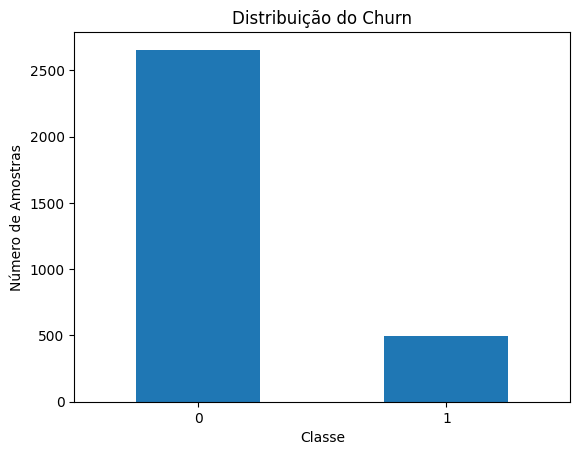

In [12]:
class_counts = df[TARGET_COLUMN].value_counts()

class_counts.plot(kind='bar')

plt.title('Distribuição do Churn')
plt.xlabel('Classe')
plt.ylabel('Número de Amostras')
plt.xticks(rotation=0)

plt.show()

In [13]:
print(class_counts)

Churn
0    2655
1     495
Name: count, dtype: int64


O dataset é desbalanceado, uma vez que há 2655 registros com valor 0 e 495 registros com valor 1. São mais de 5x mais registros com valor 0 do que com valor 1.

### <font color='#2D9CDB'>Q3) Gere a matriz de correlação entre os atributos do dataset e a variável alvo utilizando o gráfico fornecido e, com base nos valores apresentados, identifique quais atributos possuem maior correlação (positiva ou negativa) com a variável alvo, indicando quais podem ser mais relevantes para o problema de classificação.</font>

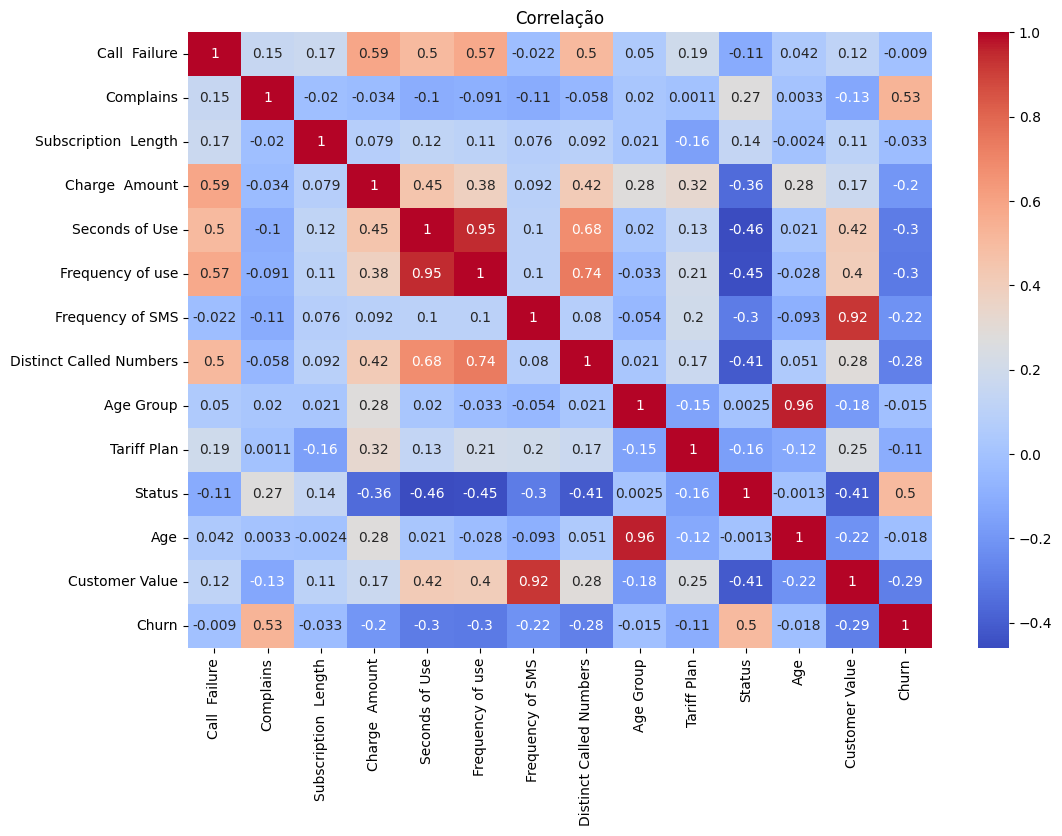

In [17]:
df_numerico = df.select_dtypes(include=['int64', 'float64'])

corr = df_numerico.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title('Correlação')
plt.show()

In [16]:
print(corr[TARGET_COLUMN].sort_values(ascending=False))

Churn                      1.000000
Complains                  0.532053
Status                     0.498976
Call  Failure             -0.008987
Age Group                 -0.014550
Age                       -0.017705
Subscription  Length      -0.032588
Tariff Plan               -0.105853
Charge  Amount            -0.202305
Frequency of SMS          -0.220754
Distinct Called Numbers   -0.278867
Customer Value            -0.289144
Seconds of Use            -0.298935
Frequency of use          -0.303337
Name: Churn, dtype: float64


As variáveis que possuem maior correlação com o Churn são:

- Complains: 0.53
- Status: 0.49
- Seconds of Use: -0.29
- Frequency of Use: -0.30

### <font color='#2D9CDB'>Q4) Aplique a técnica de Análise de Componentes Principais (PCA) para projetar os dados em duas dimensões e gere um gráfico de dispersão (scatter plot) utilizando as duas primeiras componentes principais, colorindo os pontos de acordo com a variável alvo; antes de aplicar o PCA, padronize os dados utilizando `StandardScaler`; em seguida, com base na visualização obtida, analise se há separação entre as classes e justifique sua resposta considerando a presença ou não de sobreposição entre os grupos.</font>

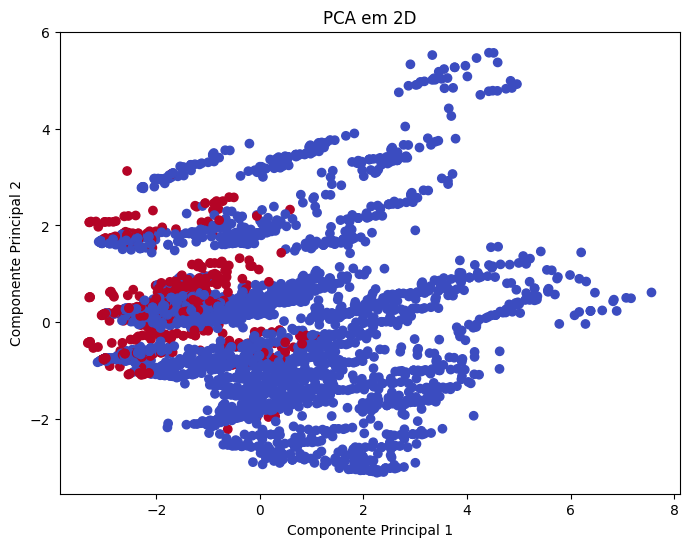

In [18]:
X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y,
    cmap='coolwarm'
)

plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('PCA em 2D')

plt.show()

O gráfico gerado mostra sobreposição significativa entre os grupos, com as duas classes são se separando claramente. Isso acontece pois as correlações com o Churn são moderadas, o que indica que nenhuma variável individual separa claramente as classes.

### <font color='#2D9CDB'>Q5) Separe o dataset em variáveis de entrada (`X`) e variável alvo (`y`), divida os dados em conjuntos de treino e teste utilizando `train_test_split` (com 20% para teste) e `random_state=42`, e aplique a padronização dos atributos com `StandardScaler`; em seguida, explique por que a padronização é importante nesse contexto e por que o `fit` deve ser aplicado apenas no conjunto de treino.

In [21]:
X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (2520, 13)
X_test: (630, 13)
y_train: (2520,)
y_test: (630,)


A padronização é importante porque os atributos possuem escalas muito diferentes e com o StandardScaler, todos os atributos passam a ter média 0 e desvio padrão 1, o que equilibra sua influência no modelo. O fit deve ser aplicado apenas no conjunto de treino pois é nessa etapa que a média e o desvio padrão são calculados. Aplicar o fit também nos dados de teste caracterizaria data leakage.

### <font color='#2D9CDB'>Q6) Treine um modelo de regressão logística utilizando os dados de treino (`X_train`, `y_train`) e, após o treinamento, verifique se o modelo convergiu corretamente; em seguida, descreva qual é o papel desse modelo no contexto do problema e o que ele está aprendendo a partir dos dados.</font>

In [22]:
modelo = LogisticRegression()

modelo.fit(X_train, y_train)

print("Iterações:", modelo.n_iter_)

Iterações: [42]


O modelo foi treinado nos dados de treino e convergiu em 42 iterações, o que indica que encontrou uma solução estável.

No contexto do problema, o modelo está aprendendo a relacionar os atributos dos clientes com o Churn. Do ponto de vista matemático, ele aprende um conjunto de pesos para cada atributo, combinando-os em uma função logística que transforma a soma ponderada em uma probabilidade entre 0 e 1

### <font color='#2D9CDB'>Q7) Utilize o modelo treinado para calcular as probabilidades previstas para o conjunto de teste (`predict_proba`) e exiba algumas delas; em seguida, interprete os valores obtidos explicando o que cada coluna representa e analise se o modelo está fazendo previsões com alta ou baixa confiança, com base na proximidade dos valores de 0 e 1.</font>

In [23]:
y_proba = modelo.predict_proba(X_test)

print(y_proba[:10])

[[9.98819220e-01 1.18078042e-03]
 [9.99954113e-01 4.58869561e-05]
 [9.74259483e-01 2.57405165e-02]
 [9.99517602e-01 4.82398265e-04]
 [9.98645143e-01 1.35485663e-03]
 [9.97154922e-01 2.84507844e-03]
 [9.91458577e-01 8.54142300e-03]
 [9.91454963e-01 8.54503750e-03]
 [9.87024986e-01 1.29750142e-02]
 [5.90190333e-01 4.09809667e-01]]


O método predict_proba retorna duas probabilidades para cada amostra, em que a primeira coluna representa a probabilidade do cliente não cancelar e a segunda do cliente cancelar.

Com os 10 primeiros resultados é possível ver que o modelo está fazendo previsões com confiança, já que em uma das colunas a probabilidade é maior que 90%. Mas a última amostra exibida mostra uma previsão menos confiante, o que pode ser reflexo do desbalanceamento do dataset, onde o modelo tende a prever a classe majoritária com mais certeza.

### <font color='#2D9CDB'>Q8) Utilize as probabilidades previstas para gerar classificações com dois limiares diferentes (0.5 e 0.7) e compare os resultados obtidos; em seguida, analise como a alteração do limiar afeta as previsões do modelo, especialmente em relação à quantidade de falsos positivos e falsos negativos.</font>

In [24]:
proba_classe1 = y_proba[:, 1]

y_pred_05 = (proba_classe1 >= 0.5).astype(int)
y_pred_07 = (proba_classe1 >= 0.7).astype(int)

print("Matriz de confusão limiar 0.5")
print(confusion_matrix(y_test, y_pred_05))

print("Matriz de confusão limiar 0.7")
print(confusion_matrix(y_test, y_pred_07))

Matriz de confusão limiar 0.5
[[504  16]
 [ 66  44]]
Matriz de confusão limiar 0.7
[[514   6]
 [ 74  36]]


Com o aumento do limiar de 0.5 para 0.7, o modelo passa a classifcar um cliente com churn apenas quando tem pelo menos 70% de confiaça, mais conservados para previsões positivas. Já com um limiar de 0.5, a matriz de confusão mostra 16 falsos positivos e 66 falsos negativos, enquanto com 0.7 os falsos positivos caem para 6, mas os falsos negativos aumentam para 74.

Ou seja, com limiar mais alto o modelo erra menos ao apontar clientes que não vão cancelar como churn, mas erra com clientes que de fato vão fazê-lo.

### <font color='#2D9CDB'>Q9) Calcule as métricas de desempenho (acurácia, precisão, recall e F1-score) e a matriz de confusão para os dois limiares de decisão (0.5 e 0.7) utilizando a função fornecida e, com base nos resultados obtidos, compare o desempenho do modelo, identificando qual métrica foi mais impactada pela mudança do limiar e discutindo o trade-off observado entre precisão e recall.</font>

In [25]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("RESULTADOS LIMIAR 0.5")

print("Acurácia:", accuracy_score(y_test, y_pred_05))
print("Precisão:", precision_score(y_test, y_pred_05))
print("Recall:", recall_score(y_test, y_pred_05))
print("F1-score:", f1_score(y_test, y_pred_05))

print("\nMatriz de confusão:")
print(confusion_matrix(y_test, y_pred_05))

print("\n=========================\n")

print("RESULTADOS LIMIAR 0.7")

print("Acurácia:", accuracy_score(y_test, y_pred_07))
print("Precisão:", precision_score(y_test, y_pred_07))
print("Recall:", recall_score(y_test, y_pred_07))
print("F1-score:", f1_score(y_test, y_pred_07))

print("\nMatriz de confusão:")
print(confusion_matrix(y_test, y_pred_07))

RESULTADOS LIMIAR 0.5
Acurácia: 0.8698412698412699
Precisão: 0.7333333333333333
Recall: 0.4
F1-score: 0.5176470588235295

Matriz de confusão:
[[504  16]
 [ 66  44]]


RESULTADOS LIMIAR 0.7
Acurácia: 0.873015873015873
Precisão: 0.8571428571428571
Recall: 0.32727272727272727
F1-score: 0.47368421052631576

Matriz de confusão:
[[514   6]
 [ 74  36]]


O recall foi a métrica mais impactada, caindo de 0.40 para 0.33 ao aumentar o limiar de 0.5 para 0.7, enquanto a precisão subiu de 0.73 para 0.86.

Esse é o trade-off esperado, com um limiar mais alto torna o modelo mais seletivo, acertando mais quando prevê churn, mas deixando de identificar mais clientes que de fato cancelariam.

O F1-score caiu de 0.52 para 0.47, indicando piora geral e a acurácia ficou estável, o que confirma que ela não é uma boa métrica isolada para dados desbalanceados.

# <font color='green'><u><b>Parte 2 - Classificação Multiclasse</b></u></font>

### <font color='#2D9CDB'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='#2D9CDB'>Blackard, J. (1998). Covertype Dataset. UCI Machine Learning Repository.</font>
  - #### <font color='#2D9CDB'>https://doi.org/10.24432/C50K5N</font>
  - #### <font color='#2D9CDB'>https://archive-beta.ics.uci.edu/dataset/31/covertype</font>

O dataset Covertype pertence ao domínio da biologia/ecologia florestal e tem como objetivo classificar pixels de áreas florestais em 7 tipos de cobertura vegetal a partir de variáveis cartográficas, considerando dados de quatro áreas selvagens da Roosevelt National Forest. Ele contém 581.012 amostras e 54 atributos, incluindo variáveis quantitativas como elevação, aspecto, declive, distâncias horizontais e verticais a corpos d'água, estradas e focos de incêndio, índices de sombreamento em diferentes horários, além de variáveis qualitativas binárias indicando a área selvagem e o tipo de solo, tendo como variável alvo o Cover_Type.

In [26]:
# fetch dataset
ds = fetch_ucirepo(id=31)

# metadata
display(ds.metadata)

# variable information
display(ds.variables)

# data (as pandas dataframe)
df = pd.concat([ds.data.features, ds.data.targets], axis='columns').sample(frac=0.10, random_state=42)

{'uci_id': 31,
 'name': 'Covertype',
 'repository_url': 'https://archive.ics.uci.edu/dataset/31/covertype',
 'data_url': 'https://archive.ics.uci.edu/static/public/31/data.csv',
 'abstract': 'Classification of pixels into 7 forest cover types based on attributes such as elevation, aspect, slope, hillshade, soil-type, and more.',
 'area': 'Biology',
 'tasks': ['Classification'],
 'characteristics': ['Multivariate'],
 'num_instances': 581012,
 'num_features': 54,
 'feature_types': ['Categorical', 'Integer'],
 'demographics': [],
 'target_col': ['Cover_Type'],
 'index_col': None,
 'has_missing_values': 'no',
 'missing_values_symbol': None,
 'year_of_dataset_creation': 1998,
 'last_updated': 'Sat Mar 16 2024',
 'dataset_doi': '10.24432/C50K5N',
 'creators': ['Jock Blackard'],
 'intro_paper': None,
 'additional_info': {'summary': 'Predicting forest cover type from cartographic variables only (no remotely sensed data).  The actual forest cover type for a given observation (30 x 30 meter cell

,name,role,type,demographic,description,units,missing_values
0,Elevation,Feature,Integer,None,None,None,no
1,Aspect,Feature,Integer,None,None,None,no
2,Slope,Feature,Integer,None,None,None,no
3,Horizontal_Distance_To_Hydrology,Feature,Integer,None,None,None,no
4,Vertical_Distance_To_Hydrology,Feature,Integer,None,None,None,no
5,Horizontal_Distance_To_Roadways,Feature,Integer,None,None,None,no
6,Hillshade_9am,Feature,Integer,None,None,None,no
7,Hillshade_Noon,Feature,Integer,None,None,None,no
8,Hillshade_3pm,Feature,Integer,None,None,None,no
9,Horizontal_Distance_To_Fire_Points,Feature,Integer,None,None,None,no


### <font color='#2D9CDB'>Q10) Exiba as primeiras linhas do dataframe, verifique suas dimensões e identifique a variável alvo (`TARGET_COLUMN`), respondendo com base nos resultados obtidos: quantas amostras e atributos o dataset possui, qual é o nome da variável alvo e se o problema é de classificação binária (justifique observando os valores únicos da variável alvo).</font>

In [30]:
display(df.head())

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Wilderness_Area2,Wilderness_Area3,Wilderness_Area4,Cover_Type
250728,3351,206,27,726,124,3813,192,252,180,2271,...,0,0,0,1,0,0,0,0,0,1
246788,2732,129,7,212,1,1082,231,236,137,912,...,0,0,0,0,0,0,0,1,0,2
407714,2572,24,9,201,25,957,216,222,142,2191,...,0,0,0,0,0,0,0,1,0,2
25713,2824,69,13,417,39,3223,233,214,110,6478,...,0,0,0,0,0,0,0,0,0,2
21820,2529,84,5,120,9,1092,227,231,139,4983,...,0,0,0,0,0,0,0,0,0,2


In [28]:
print("Dimensões do dataframe:", df.shape)

Dimensões do dataframe: (58101, 55)


In [31]:
TARGET_COLUMN = 'Cover_Type'

É uma classificação multiclasse pois a variável alvo possui 7 valores únicos (1 a 7), que são correspondentes aos 7 tipos de cobertura florestal.

### <font color='#2D9CDB'>Q11) Plote a distribuição da variável alvo utilizando o gráfico fornecido e, com base no resultado obtido, analise a proporção entre as classes para determinar se o dataset é balanceado ou desbalanceado, justificando sua resposta a partir da contagem de amostras em cada classe.</font>

In [34]:
contagem = df[TARGET_COLUMN].value_counts().sort_index()
print(contagem)


Cover_Type
1    21297
2    28248
3     3607
4      259
5      932
6     1706
7     2052
Name: count, dtype: int64


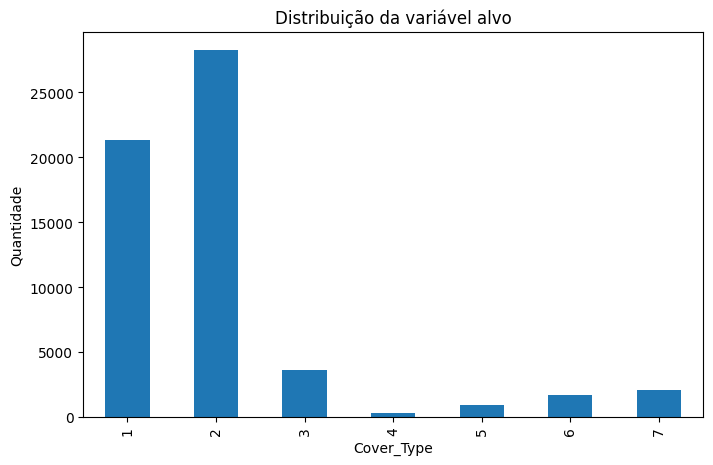

In [33]:

plt.figure(figsize=(8,5))
contagem.plot(kind='bar')
plt.xlabel('Cover_Type')
plt.ylabel('Quantidade')
plt.title('Distribuição da variável alvo')
plt.show()

O dataset é desbalanceado, uma vez que classe 2 tem 28.248 amostras e a classe 1 tem 21.297, enquanto a classe 4 tem apenas 259 amostras. Ou seja, a classe majoritária (2) tem mais de 100 vezes mais amostras que a minoritária (4). As classes 3, 5, 6 e 7 também são bastante minoritárias em comparação às classes 1 e 2.

### <font color='#2D9CDB'>Q12) Gere a correlação entre os atributos e a variável alvo, ordene os valores e plote um gráfico de barras horizontais; destaque, no gráfico, os atributos com maior correlação em valor absoluto utilizando linhas de referência em |r| = 0.2 (valor adotado como um limiar heurístico para indicar correlações moderadas); em seguida, com base nos resultados, identifique quais variáveis podem ser mais relevantes para o modelo. Opcionalmente, pode-se imprimir os valores de correlação para facilitar a verificação numérica dos resultados e complementar a análise visual do gráfico.</font>

In [35]:
correlacoes = df.corr()[TARGET_COLUMN].drop(TARGET_COLUMN).sort_values()
print(correlacoes)

Elevation                            -0.268264
Wilderness_Area1                     -0.200715
Horizontal_Distance_To_Roadways      -0.155258
Soil_Type22                          -0.140253
Soil_Type23                          -0.133668
Soil_Type29                          -0.123732
Horizontal_Distance_To_Fire_Points   -0.109868
Hillshade_Noon                       -0.094159
Soil_Type32                          -0.078483
Soil_Type24                          -0.065993
Soil_Type31                          -0.064168
Soil_Type33                          -0.063686
Hillshade_3pm                        -0.050833
Wilderness_Area2                     -0.048265
Soil_Type19                          -0.039402
Soil_Type20                          -0.030760
Hillshade_9am                        -0.029857
Horizontal_Distance_To_Hydrology     -0.024854
Soil_Type21                          -0.022818
Soil_Type12                          -0.022214
Soil_Type30                          -0.011948
Soil_Type27  

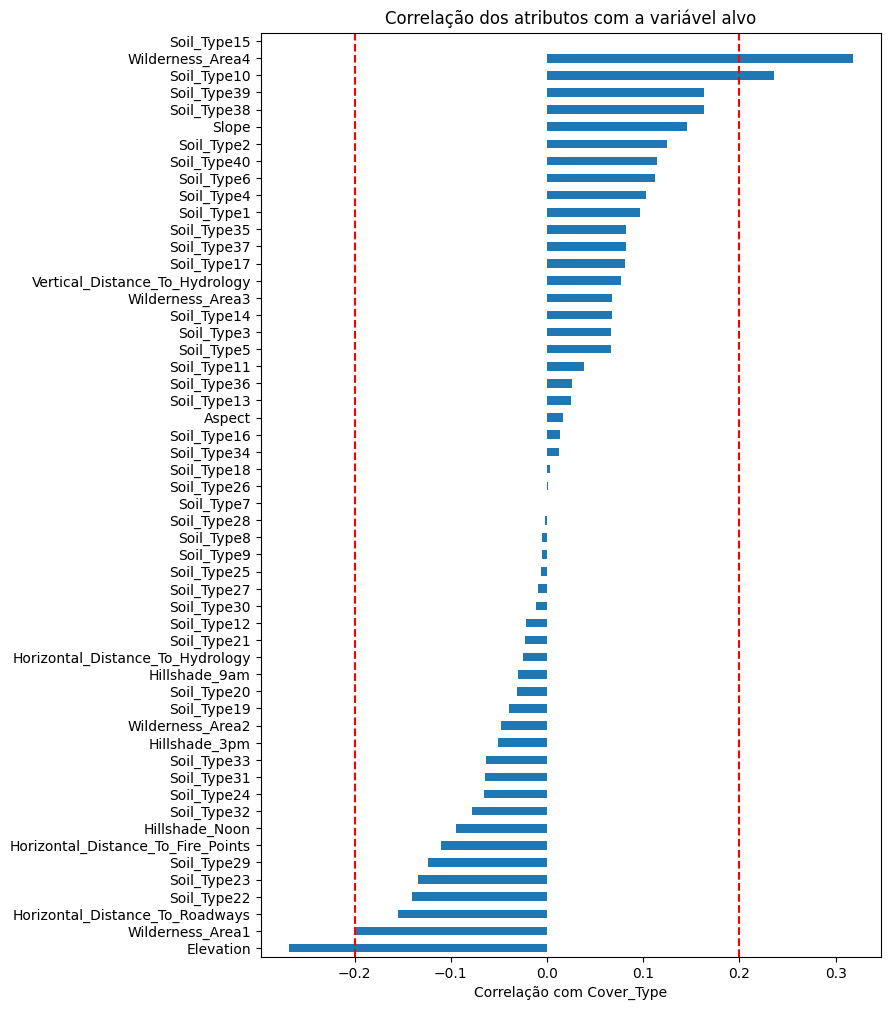

In [36]:
plt.figure(figsize=(8,12))
correlacoes.plot(kind='barh')
plt.axvline(x=0.2, color='red', linestyle='--')
plt.axvline(x=-0.2, color='red', linestyle='--')
plt.xlabel('Correlação com Cover_Type')
plt.title('Correlação dos atributos com a variável alvo')
plt.show()

Os atributos mais relvantes são:

- Wilderness_Area4 0.32
- Elevation -0.27
- Soil_Type10 0.24
- Wilderness_Area1 -0.20

### <font color='#2D9CDB'>Q13) Aplique a técnica de Análise de Componentes Principais (PCA) para projetar os dados em duas dimensões e gere um gráfico de dispersão (scatter plot) utilizando as duas primeiras componentes principais, colorindo os pontos de acordo com a variável alvo; em seguida, com base na visualização obtida, analise se há separação entre as classes e justifique sua resposta considerando a presença ou não de sobreposição entre os grupos.</font>

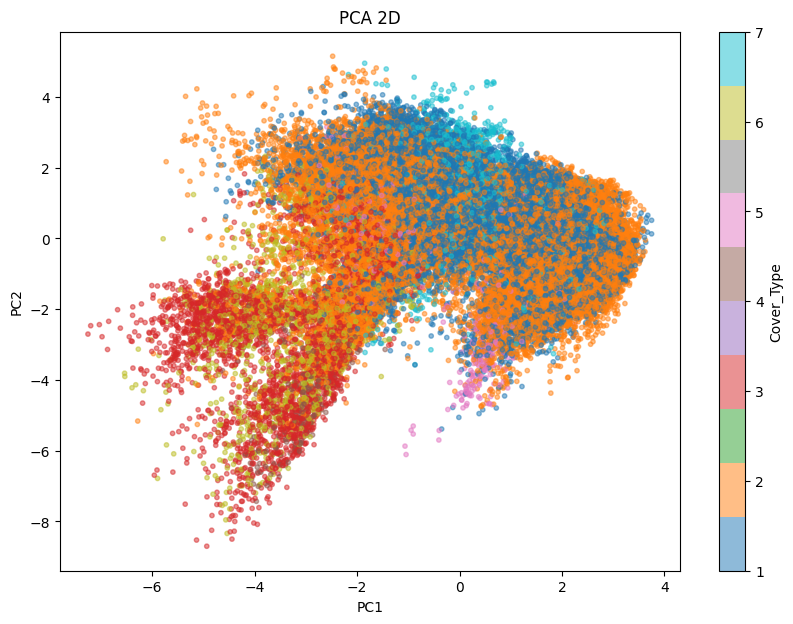

In [38]:
X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10,7))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='tab10', alpha=0.5, s=10)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA 2D')
plt.colorbar(scatter, label='Cover_Type')
plt.show()

A projeção mostra que não há separação clara entre as classes, com bastante sobreposição entre os grupos.

As classes 1 e 2 ocupam praticamente a mesma região no canto direito do gráfico, já as classes 3 e 6 aparecem mais concentradas na região inferior esquerda, mas também se misturam entre si.

As classes minoritárias (4, 5 e 7) aparecem dispersas e sobrepostas às outras. Isso indica que as duas primeiras componentes principais não capturam informação suficiente para separar linearmente as classes, sugerindo que o problema possui uma estrutura mais complexa que exige modelos não lineares ou o uso de mais componentes.

### <font color='#2D9CDB'>Q14) Separe o dataset em variáveis de entrada (`X`) e variável alvo (`y`), divida os dados em conjuntos de treino e teste utilizando `train_test_split` (com 20% para teste) e `random_state=42`, aplique a padronização dos atributos com `StandardScaler` e instancie um objeto de validação cruzada `KFold` com 5 divisões; em seguida, explique por que a validação cruzada (k-fold cross-validation) é importante para avaliar o desempenho de modelos de classificação.</font>

In [39]:
X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

print("Treino:", X_train.shape, "Teste:", X_test.shape)

Treino: (46480, 54) Teste: (11621, 54)


A validação cruzada é importante porque avalia o modelo em diferentes divisões dos dados o que garante uma estimativa mais confiável do desempenho. Ao invés de depender de uma única separação treino/teste, que pode favorecer ou prejudicar o modelo dependendo de como os dados foram divididos, o k-fold divide o conjunto em k partes e treina/avalia o modelo k vezes, usando partes diferentes para validação a cada iteração, o que reduz a variância da avaliação, ajuda a detectar overfitting e fornece uma medida mais realista de como o modelo se comportará em dados novos.

### <font color='#2D9CDB'>Q15) Utilize o objeto `KFold` instanciado anteriormente para treinar e avaliar um modelo de regressão logística multiclasse ao longo dos 5 folds no conjunto de treino, aplicando a padronização dentro de cada fold; durante o treinamento, exiba o número de iterações (`n_iter_`) em cada fold e verifique se o modelo convergiu corretamente; em seguida, reporte a média das métricas obtidas e descreva o papel do modelo no contexto do problema e o que ele está aprendendo a partir dos dados.</font>

In [41]:
acuracias = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train), 1):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    scaler_fold = StandardScaler()
    X_tr_scaled = scaler_fold.fit_transform(X_tr)
    X_val_scaled = scaler_fold.transform(X_val)

    modelo = LogisticRegression(max_iter=1000, random_state=42)
    modelo.fit(X_tr_scaled, y_tr)

    y_pred = modelo.predict(X_val_scaled)
    acc = accuracy_score(y_val, y_pred)
    acuracias.append(acc)

    print(f"Fold {fold} - n_iter: {modelo.n_iter_} - Acurácia: {acc:.4f}")

print(f"\nMédia da acurácia: {np.mean(acuracias):.4f}")

Fold 1 - n_iter: [184] - Acurácia: 0.7315
Fold 2 - n_iter: [179] - Acurácia: 0.7240
Fold 3 - n_iter: [217] - Acurácia: 0.7197
Fold 4 - n_iter: [205] - Acurácia: 0.7281
Fold 5 - n_iter: [180] - Acurácia: 0.7265

Média da acurácia: 0.7259


O modelo convergiu corretamente em todos os folds, pois o número de iterações ficou entre 179 e 217, abaixo do limite máximo definido (max_iter = 1000). A acurácia média foi de cerca de 72,59%, com pouca diferença entre os folds (de 71,97% a 73,15%), mostrando que o modelo teve um desempenho estável.

Papel do modelo no problema: a regressão logística multiclasse funciona como um classificador linear que calcula a probabilidade de cada amostra pertencer a um dos 7 tipos de cobertura florestal (Cover_Type). Como existem várias classes, o modelo usa a estratégia multinomial (softmax) e escolhe a classe com maior probabilidade.

O que o modelo está aprendendo: ele aprende a importância de cada atributo cartográfico, como elevação, declive, distâncias, sombreamento, tipo de solo e área selvagem, para diferenciar as classes. Assim, o modelo identifica quais características aumentam ou diminuem a chance de cada tipo de cobertura florestal. A acurácia em torno de 72% mostra que as classes não são perfeitamente separáveis de forma linear, o que limita o desempenho de um modelo linear nesse problem

### <font color='#2D9CDB'>Q16) Treine um modelo final de regressão logística utilizando todo o conjunto de treino (`X_train`, `y_train`), aplicando regularização L2 (padrão do `scikit-learn`) com `C=0.01`; em seguida, aplique a padronização adequada e utilize o modelo para calcular as probabilidades previstas no conjunto de teste (`predict_proba`); exiba algumas dessas probabilidades e interprete os valores obtidos, explicando o que cada coluna representa e analisando se o modelo está fazendo previsões com alta ou baixa confiança.</font>

In [42]:
modelo_reg = LogisticRegression(C=0.01, penalty='l2', max_iter=1000, random_state=42)
modelo_reg.fit(X_train_scaled, y_train)

probs_reg = modelo_reg.predict_proba(X_test_scaled)

print("Classes:", modelo_reg.classes_)
print("\nProbabilidades das 5 primeiras amostras:")
print(np.round(probs_reg[:5], 3))

Classes: [1 2 3 4 5 6 7]

Probabilidades das 5 primeiras amostras:
[[0.457 0.523 0.    0.    0.003 0.    0.017]
 [0.038 0.45  0.153 0.    0.013 0.344 0.001]
 [0.224 0.734 0.004 0.    0.022 0.011 0.004]
 [0.238 0.745 0.001 0.    0.011 0.002 0.003]
 [0.115 0.728 0.008 0.    0.035 0.113 0.   ]]


Cada coluna da matriz de probabilidades representa a chance de a amostra pertencer a uma das 7 classes, nessa ordem. A soma das probabilidades em cada linha é igual a 1.

Analisando as 5 primeiras amostras:

- Amostra 1: existe uma disputa entre a classe 1 (45,7%) e a classe 2 (52,3%), mostrando que o modelo tem baixa confiança nessa previsão.

- Amostra 2: a classe 2 possui 45% de probabilidade, enquanto a classe 6 possui 34,4%, indicando novamente baixa confiança.

- Amostra 3: a classe 2 aparece com 73,4% de probabilidade, representando uma confiança moderada.

- Amostra 4: a classe 2 possui 74,5% de probabilidade, também com confiança moderada.

- Amostra 5: a classe 2 aparece com 72,8% de probabilidade, mantendo uma confiança moderada.

De forma geral, o modelo com regularização forte realiza previsões com confiança moderada ou baixa, distribuindo as probabilidades entre várias classes ao invés de concentrar tudo em apenas uma. Isso ocorre porque um valor pequeno de C aumenta a regularização L2, penalizando coeficientes muito altos e deixando o modelo mais cauteloso. Também é possível perceber um forte viés para as classes 1 e 2, que são as mais frequentes no conjunto de dados.

### <font color='#2D9CDB'>Q17) Treine um modelo de regressão logística sem regularização (`penalty=None`) utilizando o mesmo procedimento de padronização e conjunto de treino; em seguida, calcule as probabilidades previstas no conjunto de teste (`predict_proba`), exiba algumas delas (usando os mesmos índices de amostras da questão anterior) e analise os resultados novamente.</font>

In [43]:
modelo_sem_reg = LogisticRegression(penalty=None, max_iter=1000, random_state=42)
modelo_sem_reg.fit(X_train_scaled, y_train)

probs_sem_reg = modelo_sem_reg.predict_proba(X_test_scaled)

print("Classes:", modelo_sem_reg.classes_)
print("\nProbabilidades das 5 primeiras amostras:")
print(np.round(probs_sem_reg[:5], 3))

Classes: [1 2 3 4 5 6 7]

Probabilidades das 5 primeiras amostras:
[[0.478 0.513 0.    0.    0.002 0.    0.008]
 [0.031 0.43  0.107 0.    0.013 0.419 0.   ]
 [0.199 0.776 0.001 0.    0.023 0.001 0.   ]
 [0.216 0.772 0.    0.    0.012 0.    0.   ]
 [0.101 0.762 0.004 0.    0.031 0.103 0.   ]]


Sem regularização, o modelo apresenta probabilidades mais concentradas nas classes escolhidas quando comparado ao modelo regularizado.

Na amostra 1, ainda existe uma disputa entre a classe 1 (47,8%) e a classe 2 (51,3%), mostrando pouca diferença entre elas.

Na amostra 2, a classe 2 possui 43% de probabilidade e a classe 6 possui 41,9%, deixando a disputa ainda mais equilibrada do que antes.

Na amostra 3, a probabilidade da classe 2 aumentou para 77,6%, enquanto antes era 73,4%.

Na amostra 4, a classe 2 subiu para 77,2%, acima dos 74,5% anteriores.

Na amostra 5, a classe 2 chegou a 76,2%, enquanto antes era 72,8%.

De maneira geral, as probabilidades das classes vencedoras ficaram maiores, enquanto as das outras classes ficaram mais próximas de zero. Isso acontece porque, sem regularização, o modelo consegue ajustar os coeficientes de forma mais livre aos dados de treino, produzindo previsões mais confiantes. Apesar disso, o comportamento geral continua parecido, mas o modelo sem regularização demonstra maior confiança em suas decisões.

### <font color='#2D9CDB'>Q18) Compare as probabilidades previstas pelos modelos com e sem regularização e analise as diferenças observadas, considerando: (i) a concentração das probabilidades em uma única classe, (ii) o nível de confiança das previsões e (iii) possíveis indícios de overfitting; para apoiar sua análise, calcule a confiança média dos modelos (considerando, para cada amostra, a maior probabilidade prevista) e utilize esse valor na comparação.</font>

In [44]:
confianca_reg = probs_reg.max(axis=1).mean()
confianca_sem_reg = probs_sem_reg.max(axis=1).mean()

print(f"Confiança média (com regularização C=0.01): {confianca_reg:.4f}")
print(f"Confiança média (sem regularização):        {confianca_sem_reg:.4f}")

Confiança média (com regularização C=0.01): 0.7025
Confiança média (sem regularização):        0.7276


O modelo sem regularização concentra mais as probabilidades na classe escolhida, enquanto o modelo com regularização distribui melhor as probabilidades entre as classes. Isso faz com que o modelo sem regularização tenha maior confiança nas previsões, com média de 72,76%, contra 70,25% do modelo regularizado. Porém, essa confiança maior pode indicar overfitting, já que o modelo pode estar se ajustando demais aos dados de treino. Já a regularização L2 com C = 0.01 deixa o modelo mais conservador ao penalizar coeficientes altos, reduzindo o risco de overfitting, mesmo que isso diminua um pouco a confiança das previsões.

### <font color='#2D9CDB'>Q19) Utilize o `classification_report` para avaliar o desempenho dos modelos com e sem regularização no conjunto de teste; em seguida, compare os resultados obtidos, analisando as métricas de precisão, recall e F1-score para cada classe e discutindo possíveis diferenças no desempenho entre os modelos.</font>

In [45]:
y_pred_reg = modelo_reg.predict(X_test_scaled)
y_pred_sem_reg = modelo_sem_reg.predict(X_test_scaled)

print("=== Modelo COM regularização (C=0.01) ===")
print(classification_report(y_test, y_pred_reg))

print("=== Modelo SEM regularização ===")
print(classification_report(y_test, y_pred_sem_reg))

=== Modelo COM regularização (C=0.01) ===
              precision    recall  f1-score   support

           1       0.71      0.70      0.70      4163
           2       0.75      0.81      0.78      5759
           3       0.62      0.84      0.71       720
           4       0.40      0.11      0.17        55
           5       1.00      0.01      0.01       178
           6       0.51      0.12      0.20       339
           7       0.67      0.52      0.58       407

    accuracy                           0.72     11621
   macro avg       0.67      0.44      0.45     11621
weighted avg       0.72      0.72      0.71     11621

=== Modelo SEM regularização ===
              precision    recall  f1-score   support

           1       0.71      0.70      0.70      4163
           2       0.76      0.80      0.78      5759
           3       0.64      0.79      0.71       720
           4       0.58      0.35      0.43        55
           5       0.50      0.01      0.01       178
   

Os dois modelos tiveram desempenho geral parecido, com acurácia entre 72% e 73%. Nas classes majoritárias (1, 2 e 3), os resultados foram praticamente iguais. As maiores diferenças apareceram nas classes minoritárias, em que o modelo sem regularização apresentou melhores valores de recall e f1-score, principalmente nas classes 4 e 6. A classe 5 continuou com desempenho muito baixo nos dois casos devido ao forte desbalanceamento dos dados. O macro F1 também foi maior no modelo sem regularização, mostrando um desempenho mais equilibrado entre as classes. Isso indica que a regularização forte (C = 0.01) acabou prejudicando a identificação das classes raras, enquanto o modelo sem regularização conseguiu capturar melhor esses padrões, sem apresentar sinais claros de overfitting no conjunto de teste.

### <font color='#2D9CDB'>Q20) Calcule a matriz de confusão normalizada (por linha, com duas casas de precisão) para os modelos com e sem regularização no conjunto de teste; em seguida, plote ambas as matrizes e compare os resultados, analisando quais classes são melhor classificadas, quais apresentam maior confusão e como a regularização impacta o desempenho entre as classes.</font>

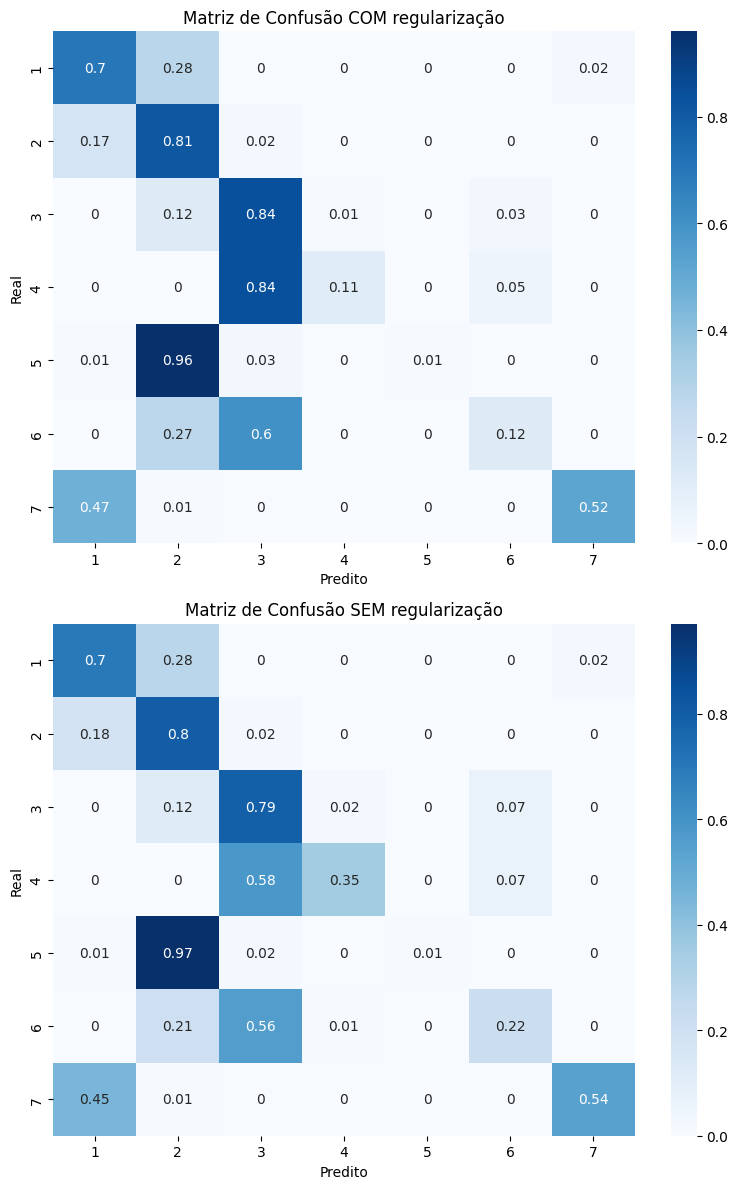

In [48]:
cm_reg = confusion_matrix(y_test, y_pred_reg, normalize='true').round(2)
cm_sem_reg = confusion_matrix(y_test, y_pred_sem_reg, normalize='true').round(2)

fig, axes = plt.subplots(2, 1, figsize=(8,12))

sns.heatmap(cm_reg, annot=True, cmap='Blues', xticklabels=[1,2,3,4,5,6,7], yticklabels=[1,2,3,4,5,6,7], ax=axes[0])
axes[0].set_title('Matriz de Confusão COM regularização')
axes[0].set_xlabel('Predito')
axes[0].set_ylabel('Real')

sns.heatmap(cm_sem_reg, annot=True, cmap='Blues', xticklabels=[1,2,3,4,5,6,7], yticklabels=[1,2,3,4,5,6,7], ax=axes[1])
axes[1].set_title('Matriz de Confusão SEM regularização')
axes[1].set_xlabel('Predito')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()

As classes 2 e 3 foram as melhor classificadas nos dois modelos, seguidas pela classe 1. Já as maiores confusões ocorreram nas classes minoritárias. A classe 5 teve o pior desempenho em ambos os casos, sendo quase sempre confundida com a classe 2. A classe 4 também apresentou muita confusão com a classe 3, mas melhorou bastante sem regularização, aumentando significativamente a taxa de acerto. O mesmo aconteceu com a classe 6, que continuou sendo confundida principalmente com a classe 3, mas teve melhora no modelo sem regularização. A classe 7 foi frequentemente confundida com a classe 1.

De forma geral, a regularização forte (C = 0.01) favoreceu as classes majoritárias e prejudicou as minoritárias, empurrando muitas previsões para as classes 1, 2 e 3. Sem regularização, o modelo conseguiu identificar melhor padrões das classes raras, principalmente da classe 4, apresentando um comportamento mais equilibrado entre as classes.